In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv(r"C:\Users\syamg\Downloads\house_prices.csv.zip")

In [41]:
df.sample(7,random_state=42)

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
99649,99649,2 BHK Ready to Occupy Flat for sale in One Raj...,The mentioned Price indicates only the Base Pr...,1.20 Cr,9646.0,kolkata,740 sqft,Ready to Move,NaN,New Property,...,NaN,Main Road,One Rajarhat,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
20299,20299,2 BHK Ready to Occupy Flat for sale A Narayana...,This gorgeous 2 BHK Flat is available for sale...,65 Lac,4062.0,bangalore,1050 sqft,Ready to Move,4 out of 4,Resale,...,East,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN
153392,153392,3 BHK Ready to Occupy Flat for sale Doon calli...,Have a look at this immaculate 3 BHK flat for ...,98 Lac,4900.0,dehradun,NaN,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,4,NaN,NaN,NaN,2000 sqft,NaN,NaN
104329,104329,2 BHK Ready to Occupy Flat for sale in One Raj...,The mentioned Price indicates only the Base Pr...,1.20 Cr,9646.0,kolkata,740 sqft,Ready to Move,NaN,New Property,...,NaN,Main Road,One Rajarhat,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
174711,174711,3 BHK Ready to Occupy Flat for sale in Dolphin...,"New Dhamtari Road, Raipur has an attractive 3 ...",44.4 Lac,2700.0,raipur,1300 sqft,Ready to Move,1 out of 8,New Property,...,East,Main Road,Dolphin Jewel O,3,2,1 Covered,Co-operative Society,NaN,NaN,NaN
107506,107506,3 BHK Ready to Occupy Flat for sale in Diamond...,3 bedroom flat available for sale in Diamond C...,1.10 Cr,7666.0,kolkata,NaN,Ready to Move,12 out of 20,Resale,...,East,Main Road,Diamond City South,2,2,1 Open,Freehold,1435 sqft,NaN,NaN
149672,149672,2 BHK Ready to Occupy Flat for sale in Krish A...,This ready to move-in 2 BHK flat is available ...,24 Lac,2341.0,bhiwadi,NaN,Ready to Move,10 out of 13,Resale,...,North - East,Garden/Park,Krish Aura,2,4,1 Covered,Freehold,1025 sqft,NaN,NaN


In [42]:
df.shape

(187531, 21)

In [43]:
df= df.drop(range(10000,187531))

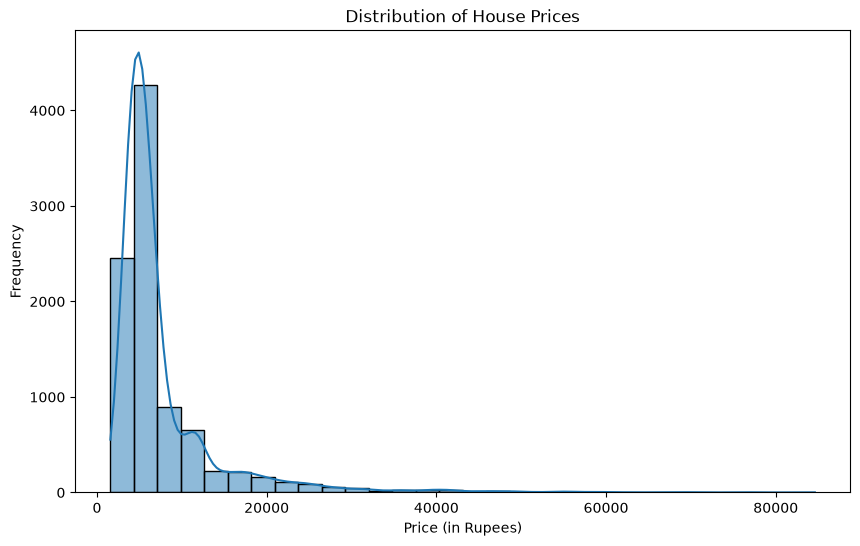

In [44]:
plt.figure(figsize=(10,6))
sns.histplot(df["Price (in rupees)"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price (in Rupees)")
plt.ylabel("Frequency")
plt.show()

In [46]:
df['Bathroom'] = pd.to_numeric(df['Bathroom'],errors='coerce')

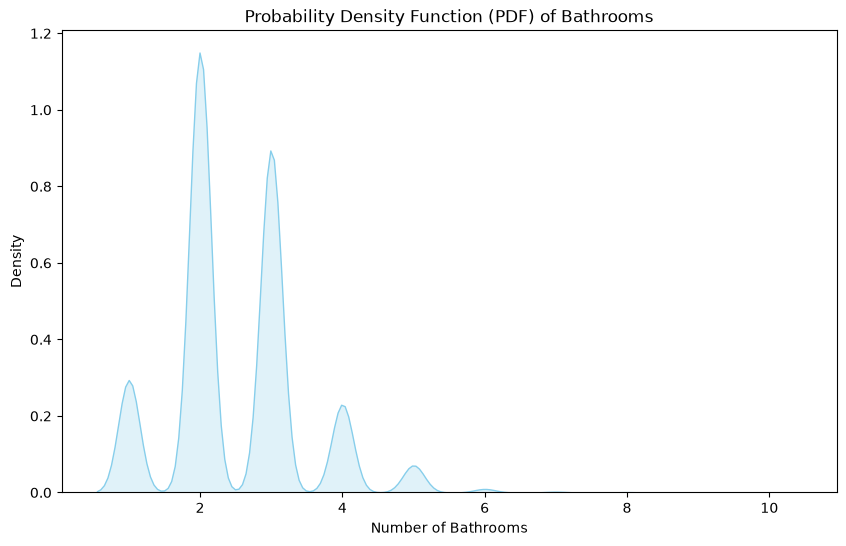

In [68]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Bathroom', fill=True, color='skyblue')
plt.title("Probability Density Function (PDF) of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Density")
plt.show()

In [62]:
df.isnull().sum()

Index                   0
Title                   0
Description           104
Amount(in rupees)       0
Price (in rupees)     652
location                0
Status                 19
Floor                 329
Transaction             9
Furnishing             80
facing               4406
overlooking          4329
Society              3964
Bathroom               31
Balcony              3540
Car Parking          5874
Ownership            3819
total_area(sqft)     1927
dtype: int64

In [49]:
df['total_area'] = df['Carpet Area'].fillna(df['Super Area'])
df = df.drop(columns=['Carpet Area','Super Area','Dimensions','Plot Area'])

In [55]:
df['total_area(sqft)'].sample(5,random_state=42)

6252    1935
4684    2000
1731     430
4742    1080
4521    1070
Name: total_area(sqft), dtype: str

In [51]:
df['total_area(sqft)'] = df['total_area']
df = df.drop(columns=['total_area'])

In [59]:
df['total_area(sqft)'] = df['total_area(sqft)'].str.replace("sqft","",regex=False).str.strip()
df['total_area(sqft)'] = df['total_area(sqft)'].str.replace("sqm","",regex=False).str.strip()

In [60]:
df['total_area(sqft)']

0        500
1        473
2        779
3        530
4        635
        ... 
9995    1100
9996    2007
9997    2623
9998      78
9999    1707
Name: total_area(sqft), Length: 10000, dtype: str

In [61]:
df['total_area(sqft)'] = pd.to_numeric(df['total_area(sqft)'],errors='coerce')

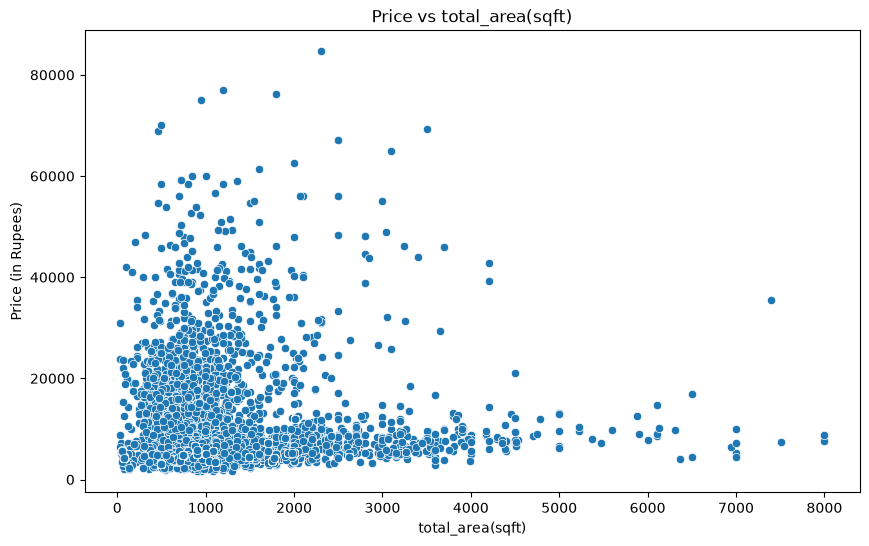

In [64]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df["total_area(sqft)"],y=df["Price (in rupees)"])
plt.title("Price vs total_area(sqft)")
plt.xlabel("total_area(sqft)")
plt.ylabel("Price (in Rupees)")
plt.show()

In [69]:
top_locations = (df.groupby("location")["Price (in rupees)"].mean().sort_values(ascending=False).head(10))
top_locations

location
mumbai         23609.574292
thane          10265.998869
navi-mumbai     9874.158209
ahmedabad       5479.886058
nagpur          4815.535593
Name: Price (in rupees), dtype: float64

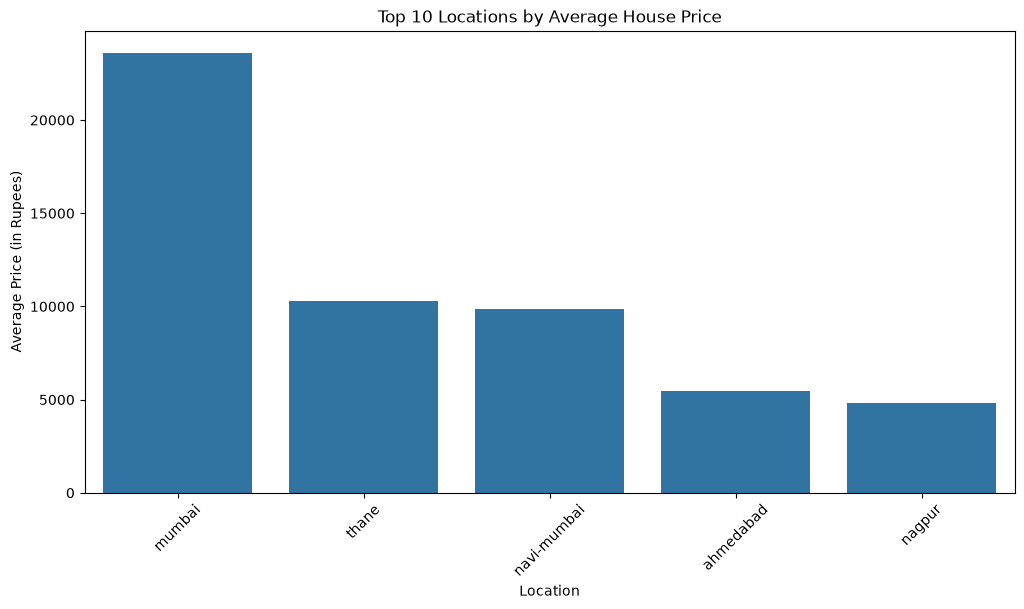

In [70]:
top_locations = (df.groupby("location")["Price (in rupees)"].mean().sort_values(ascending=False).head(10))
plt.figure(figsize=(12,6))
sns.barplot(x=top_locations.index,y=top_locations.values)
plt.title("Top 10 Locations by Average House Price")
plt.xlabel("Location")
plt.ylabel("Average Price (in Rupees)")
plt.xticks(rotation=45)
plt.show()

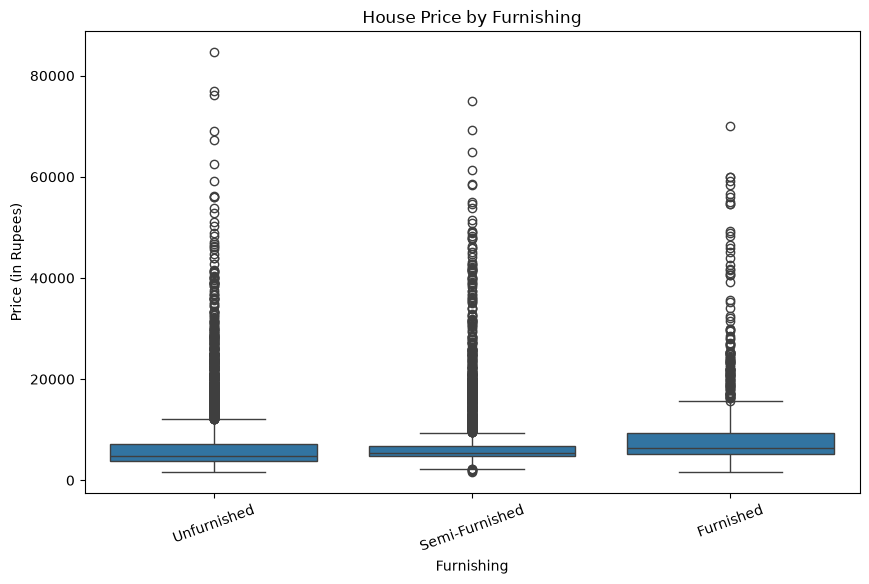

In [71]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Furnishing",y="Price (in rupees)",data=df)
plt.title("House Price by Furnishing")
plt.xlabel("Furnishing")
plt.ylabel("Price (in Rupees)")
plt.xticks(rotation=20)
plt.show()